<a href="https://colab.research.google.com/github/AmatHub21/codingan_kelompok_mechineLearning/blob/main/rombakan_codingan_MachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
student_performance = fetch_ucirepo(id=320)

# data (as pandas dataframes)
X = student_performance.data.features
y = student_performance.data.targets

# metadata
print(student_performance.metadata)

# variable information
print(student_performance.variables)


{'uci_id': 320, 'name': 'Student Performance', 'repository_url': 'https://archive.ics.uci.edu/dataset/320/student+performance', 'data_url': 'https://archive.ics.uci.edu/static/public/320/data.csv', 'abstract': 'Predict student performance in secondary education (high school). ', 'area': 'Social Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 649, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': ['Sex', 'Age', 'Other', 'Education Level', 'Occupation'], 'target_col': ['G1', 'G2', 'G3'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5TG7T', 'creators': ['Paulo Cortez'], 'intro_paper': {'ID': 360, 'type': 'NATIVE', 'title': 'Using data mining to predict secondary school student performance', 'authors': 'P. Cortez, A. M. G. Silva', 'venue': 'Proceedings of 5th Annual Future Business Technolo

In [9]:
from google.colab import files
uploaded = files.upload()

Saving student-por[1].csv to student-por[1] (1).csv


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [12]:
!pip install ucimlrepo
import pandas as pd
from ucimlrepo import fetch_ucirepo

# fetch dataset to ensure X and y are defined
student_performance = fetch_ucirepo(id=320)

# data (as pandas dataframes)
X = student_performance.data.features
y = student_performance.data.targets

# Concatenate them to form the complete DataFrame 'df'.
df = pd.concat([X, y], axis=1)

print("Ukuran dataset:", df.shape)
print(df.head())

Ukuran dataset: (649, 33)
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]


In [13]:
df["status"] = df["G3"].apply(
    lambda x: "Lulus" if x >= 10 else "Tidak Lulus"
)

print("\nJumlah masing-masing kelas:")
print(df["status"].value_counts())



Jumlah masing-masing kelas:
status
Lulus          549
Tidak Lulus    100
Name: count, dtype: int64


In [14]:
# G3 tidak dimasukkan karena G3 digunakan
# untuk membuat status kelulusan

X = df.drop(columns=["G3", "status"])
y = df["status"]


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nData training:", X_train.shape)
print("Data testing :", X_test.shape)


Data training: (519, 32)
Data testing : (130, 32)


In [16]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)


In [18]:
model = Pipeline([
    ("preprocessing", preprocessor),
    (
        "classifier",
        SGDClassifier(
            random_state=42
        )
    )
])

In [19]:
param_grid = {
    "classifier__loss": [
        "log_loss",
        "hinge"
    ],

    "classifier__alpha": [
        0.0001,
        0.001,
        0.01
    ],

    "classifier__max_iter": [
        1000,
        2000,
        3000
    ],

    "classifier__penalty": [
        "l2",
        "l1"
    ]
}

In [20]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("\nSedang melakukan optimasi...")
grid_search.fit(X_train, y_train)


Sedang melakukan optimasi...


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2'],
      dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['school', 'sex', 'address', 'f...
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object'))])),
                                       ('classifier',
                                        SGDClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__alpha': [0.0001, 0.001, 0.01],
                         'classifier__loss': ['log_loss', 'hinge'],
                         'classifier__max_iter': [1000, 2000, 3000],
                         'classifier__penalty': ['l2', 'l1']},
             scoring='accuracy')

In [21]:
print("\nParameter terbaik:")
print(grid_search.best_params_)

print("\nAkurasi cross-validation terbaik:")
print(grid_search.best_score_)



Parameter terbaik:
{'classifier__alpha': 0.0001, 'classifier__loss': 'hinge', 'classifier__max_iter': 1000, 'classifier__penalty': 'l1'}

Akurasi cross-validation terbaik:
0.9286967886482449


In [22]:
best_model = grid_search.best_estimator_

In [23]:
y_pred = best_model.predict(X_test)

In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("\n================================")
print("HASIL EVALUASI")
print("================================")

print("Akurasi:", accuracy)
print("Akurasi (%):", accuracy * 100)



HASIL EVALUASI
Akurasi: 0.9230769230769231
Akurasi (%): 92.3076923076923


In [25]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)



Classification Report:
              precision    recall  f1-score   support

       Lulus       0.96      0.95      0.95       110
 Tidak Lulus       0.73      0.80      0.76        20

    accuracy                           0.92       130
   macro avg       0.85      0.87      0.86       130
weighted avg       0.93      0.92      0.92       130



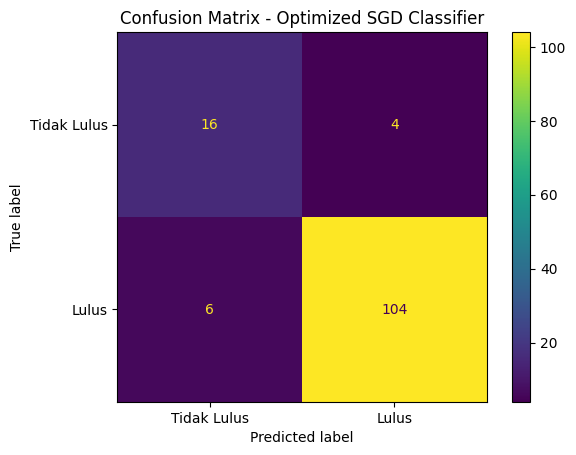

In [26]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Tidak Lulus", "Lulus"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Tidak Lulus", "Lulus"]
)

disp.plot()

plt.title("Confusion Matrix - Optimized SGD Classifier")
plt.show()